In [382]:
import src.cargar_datos as cd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import  SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
import pickle
import joblib


### Importando el archivo base_de_Datos_xlsx
    

In [383]:
df = cd.cargar_datos(r'C:\henrylocal\Module_5\MLops\base_de_datos.xlsx')
df.head()


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


### Uso del descrribe para determinar si hay inconsistencia en las variables numericas

In [384]:
# describing dataset#
df.describe()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,...,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121664,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,...,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,...,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,...,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,...,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,...,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,...,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


### Después de hacer el describe e identificar los uniques en las variables tipo objecto se detectaron las siguientest inconsistencias ###
    puntaje_datacredito
    tendencias_ingresos
    fecha_prestamo : para el EDA se mantiene para efectos de analisis bivariable
    puntaje

In [385]:
df['puntaje'] = df['puntaje'].apply(lambda x: x if x >= 0 else np.nan)
df['puntaje_datacredito'] = df['puntaje_datacredito'].apply(lambda x: x if x >= 0 else np.nan)
df['tendencia_ingresos'] = df['tendencia_ingresos'].apply(lambda x : x if isinstance(x,str)  else np.nan)
df['fecha_prestamo']= pd.to_datetime(df['fecha_prestamo']).dt.strftime("%Y-%m")


### Determinado cuales variables contienen valores nulos ###
    saldo_more
    saldo_total
    saldo_principal
    saldo_mora_codeudor
    promdeio_ingrsos_datacredito
    tendencia_ingresos
    puntaje_datacredito

In [386]:

df.isnull().sum()

tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                           135
puntaje_datacredito                 7
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2990
Pago_atiempo                        0
dtype: int64

### Imputando valores nules # 
    puntaje: con mean estratificado por tipo_laboral y pago_atiempo
    puntaje_datacredito: con mean estratificado por tipo_laboral y pago_atiempo
    promdeio_ingresos_datacredito : con mean estratificado tipo_laboral','Pago_atiempo','edad_categoria
    tendecias : con la moda de stratos
    saldo_mora : con al media
    saldo_total : con la media
    saldo_codeudor : con la media


In [387]:
p= df.groupby(['tipo_laboral','Pago_atiempo'])['puntaje'].transform('mean')
df['puntaje']  = df['puntaje'].fillna(p)
pdc = df.groupby(['tipo_laboral','Pago_atiempo'])['puntaje_datacredito'].transform('mean')
df['puntaje_datacredito'] = df['puntaje_datacredito'].fillna(pdc)
df['edad_categoria'] = df['edad_cliente'].apply(lambda x : 'joven' if x < 25 else  'old' if x > 60  else 'adult')
pi= df.groupby(['tipo_laboral','Pago_atiempo','edad_categoria'])['promedio_ingresos_datacredito'].transform('mean')
df['promedio_ingresos_datacredito'] =df['promedio_ingresos_datacredito'] .fillna(pi)
ti = df.groupby(['tipo_laboral','edad_categoria','Pago_atiempo'])['tendencia_ingresos'].transform(lambda x: x.mode()[0])
df['tendencia_ingresos'] = df['tendencia_ingresos'].fillna(ti)
sm = df.groupby(['tipo_laboral','edad_categoria','Pago_atiempo'])['saldo_mora'].transform('mean')
df['saldo_mora'] = df['saldo_mora'].fillna(sm)
st= df.groupby(['tipo_laboral','edad_categoria','Pago_atiempo'])['saldo_total'].transform('mean')
df['saldo_total'] = df['saldo_total'].fillna(st)
sp= df.groupby(['tipo_laboral','edad_categoria','Pago_atiempo'])['saldo_principal'].transform('mean')
df['saldo_principal'] = df['saldo_principal'].fillna(sp)
sd= df.groupby(['tipo_laboral','edad_categoria','Pago_atiempo'])['saldo_mora_codeudor'].transform('mean')
df['saldo_mora_codeudor'] = df['saldo_mora_codeudor'].fillna(sd)

In [388]:
df = df.sort_values('fecha_prestamo')

In [389]:
pd.DataFrame({'age':[1],'gender':['male']})


,age,gender
0,1,male


### let's analyze quickly the corralation matrix

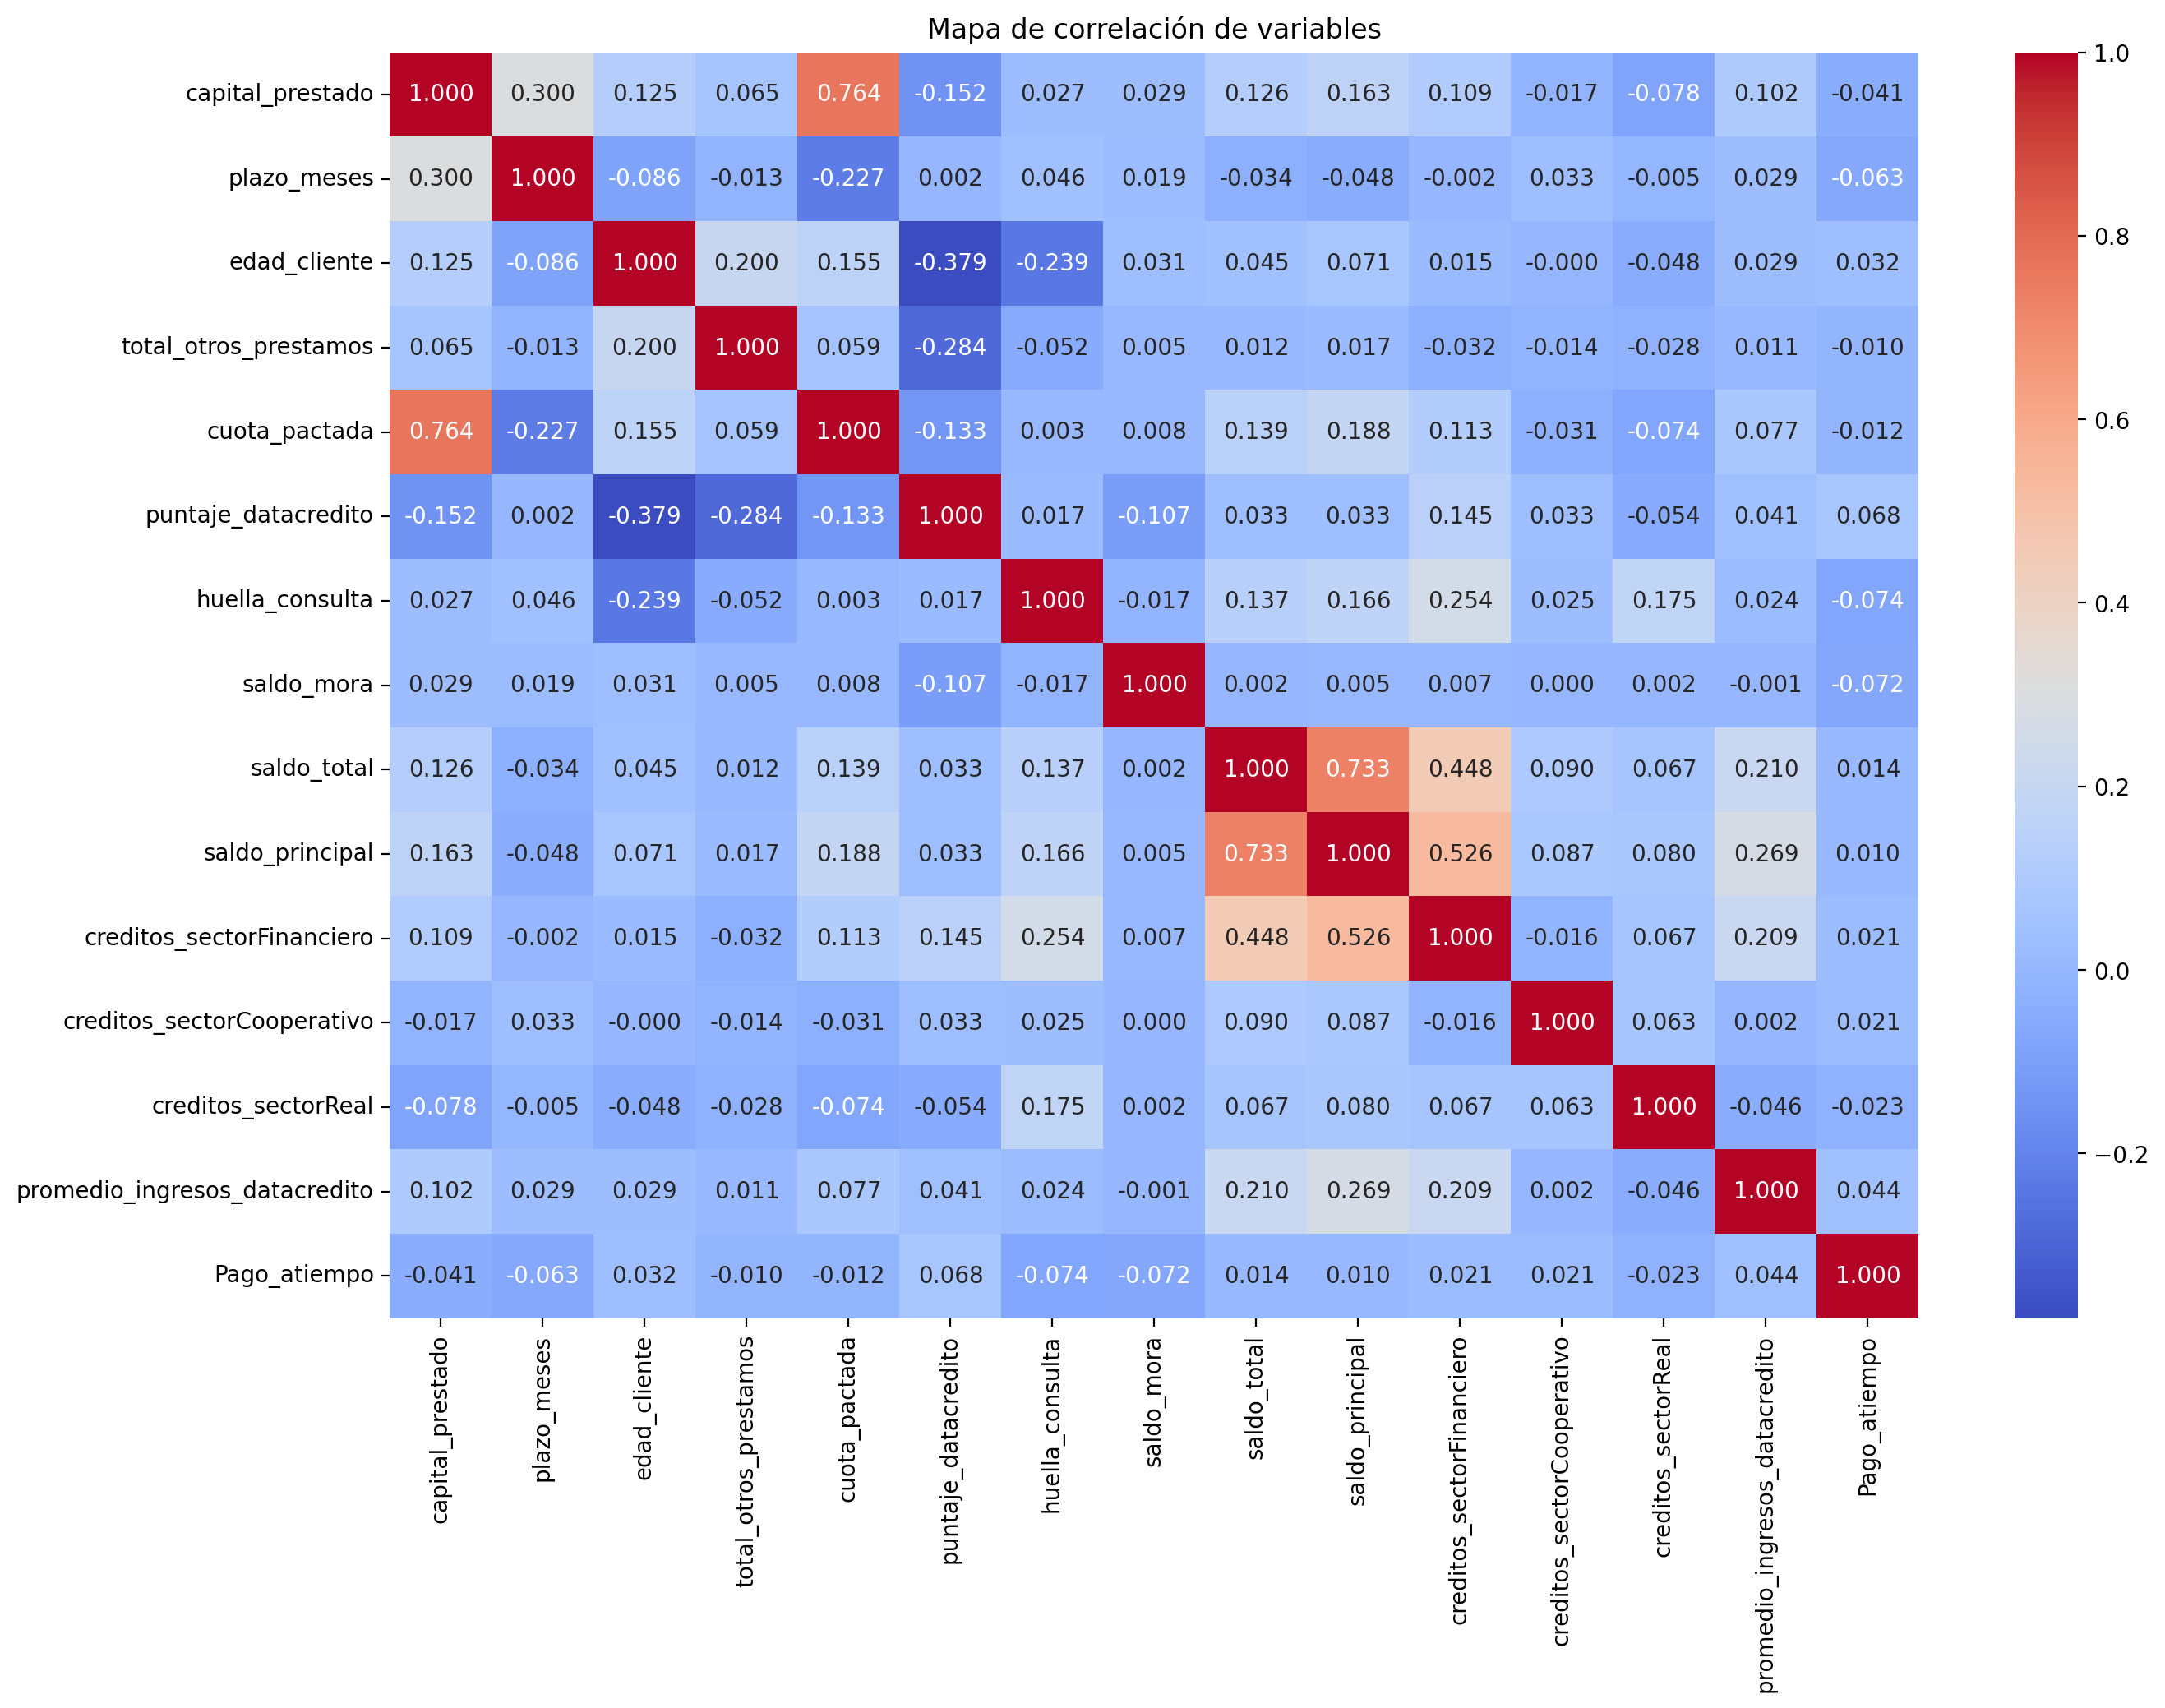

In [414]:
cor = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10), dpi= (200))
sns.heatmap(cor, annot= True, cmap=  'coolwarm', fmt= '.3f')
plt.title('Mapa de correlación de variables')

plt.show()

#### According to correlation map we need to remove a couple of variable, due to they either do not have any kind of relationship with the target or we have colineality:
     Puntaje: removed due to colineality
     Saldo_mora_codeudor: this is just noise
     cant_creditosvigentes: noise
     Salario_cliente: noise
     tipo_credito:noise

In [391]:
df = df.drop(['puntaje','saldo_mora_codeudor','cant_creditosvigentes','salario_cliente','tipo_credito'], axis = 1)

### creando analisis univariable ###
    Las variable mas relevantes a analizar for su relación con el target:
    promedio_ingresos_datacredito
    puntaje_datacredito
    edad_cliente
    capital_prestado
    plazo_meses
    saldo_mora
    consulta_huella

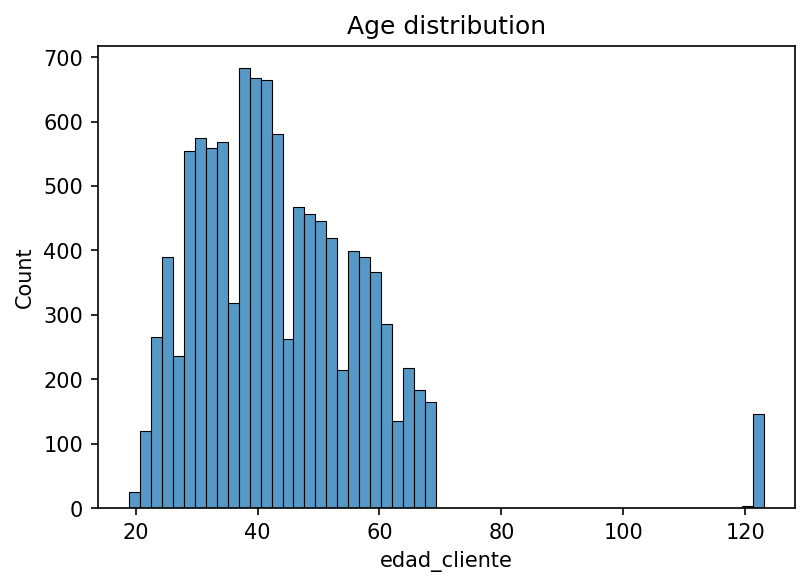

In [392]:
figure_n2 = plt.figure(figsize = (6,4), dpi = 150)
sns.histplot(df,x = 'edad_cliente')
plt.title('Age distribution')

plt.show()



##### se puede observar que el promido de edades es de 40 años con una distribucipon ligeramente sesgada a la derecha lo que implica  que hay mas cantidad de clientes mayores de 40 que los que hay menores a, sin embargo es la participación de rangos de edades va reduciendose a mediad que se incrementa la edad.
     hay valores estremos que  no fueron reemplazados debido a que es plausible encontrar clientes de esa edad, aunque raro el hecho de tener mas de 100 indica que no es de hecho un error.

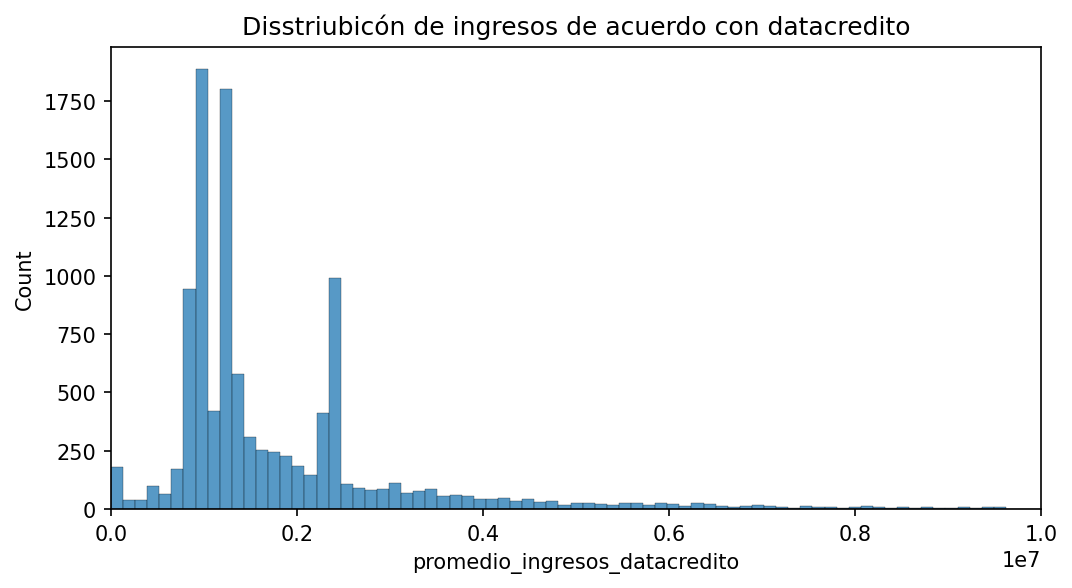

In [393]:
figure_n2 = plt.figure(figsize = (8,4), dpi = 150)
sns.histplot(df,x = 'promedio_ingresos_datacredito')
plt.title('Disstriubicón de ingresos de acuerdo con datacredito')
plt.xlim(right = 10000000 ,left = 0.0)

plt.show()

#### se puede observar que de acuerdo con data credito  los ingresos se reducen sustancialmente después de la media y también nos indica que tener clientes con ingresos mayores a 200000 es realmente dificil , siendo relativamente sencillo  para los que ganan menos que eso.
    Se resalta que cuando sea que un cliente gana más de 300 mil las probabilidades de que no pague a tiempo son casi nulas

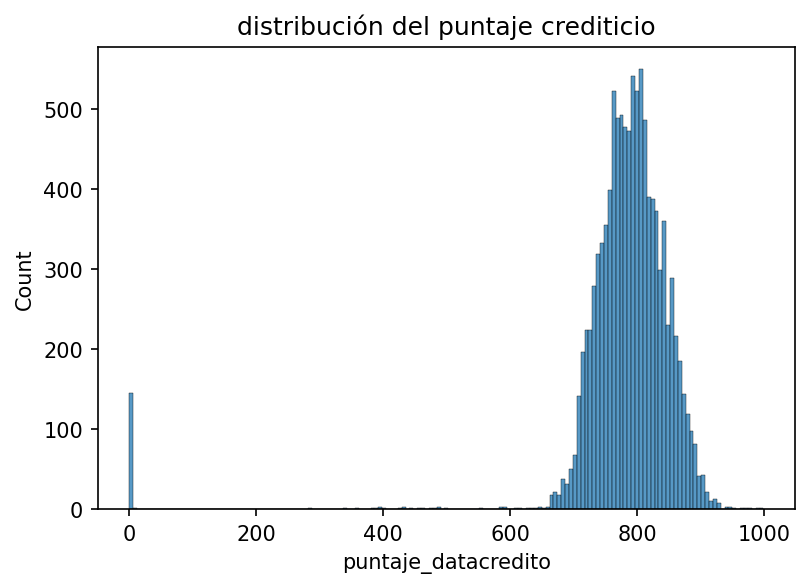

In [394]:
figure_n2 = plt.figure(figsize = (6,4), dpi = 150)
sns.histplot(df,x = 'puntaje_datacredito')
plt.title('distribución del puntaje crediticio')


plt.show()

#### se puede apreciar que la base de clientes tiene un relativamente buen score crediticio:
    Media : 800
    intervalo de confienza 650-950

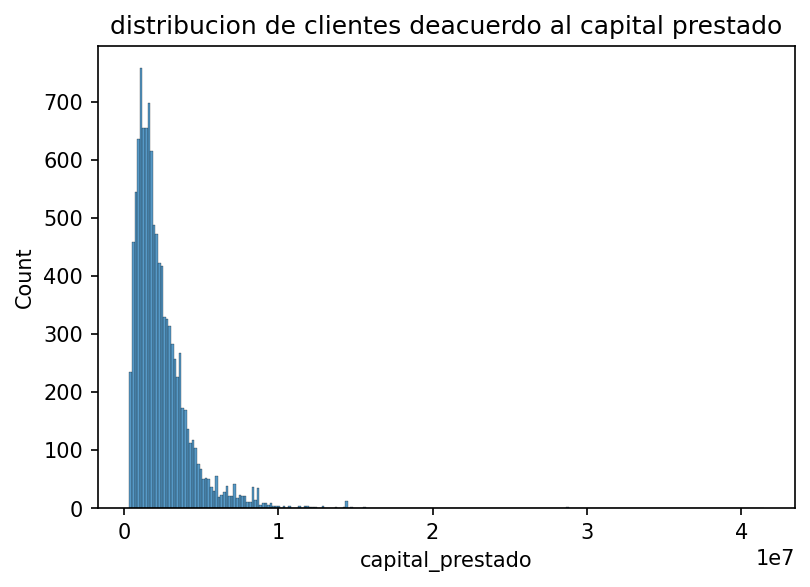

In [395]:
figure_n2 = plt.figure(figsize = (6,4), dpi = 150)
sns.histplot(df,x = 'capital_prestado')
plt.title('distribucion de clientes deacuerdo al capital prestado')


plt.show()

#### en su mayoría los clientes tienden a prestar más de 2000000 sin embargo a la cantidad de personas se reduce  a medidad que el capital crece eexponecial mente:
    el negocio se sostiene con clientes que prestan menos de 4 mill.

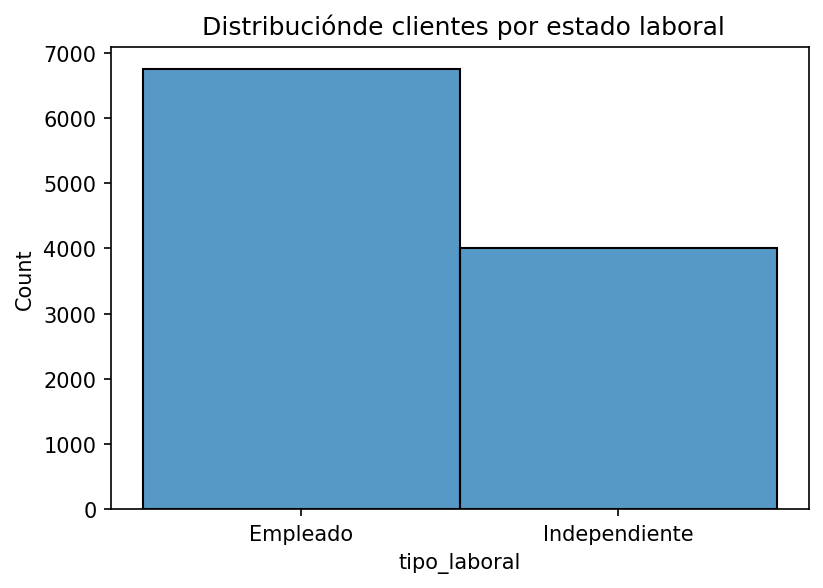

In [396]:
figure_n2 = plt.figure(figsize = (6,4), dpi = 150)
sns.histplot(df,x = 'tipo_laboral')
plt.title(' Distribuciónde clientes por estado laboral')

plt.show()


#### se observa rapidamente que la plantilla de clientes esta conformada en un 60 % por emplados y alrededor de in 40 por independientes

### now we can proceed to create univariable analysis plots and biviriate

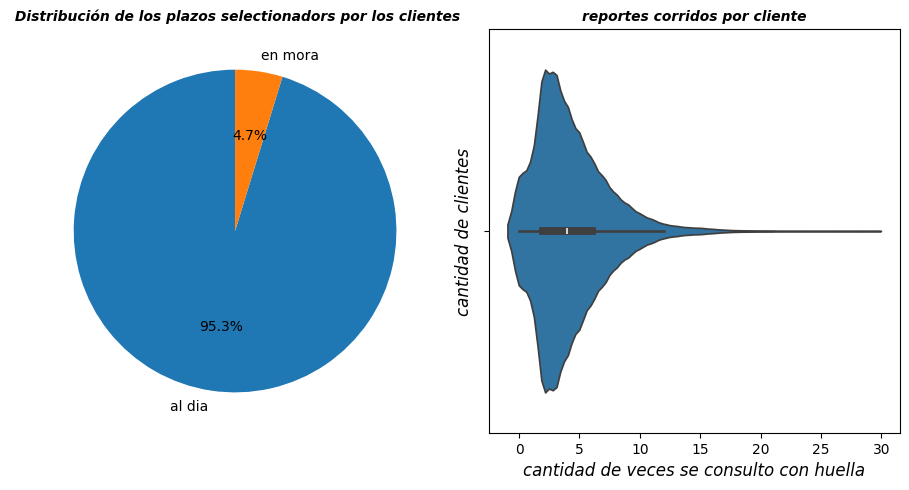

In [397]:
#univariable
figure2,ax= plt.subplots(1,2,figsize=(9,5),dpi=100)
ax[0].pie(df['Pago_atiempo'].value_counts(), labels =['al dia', 'en mora'] ,startangle=90,    autopct="%1.1f%%",)
ax[0].set_title(' Distribución de los plazos selectionadors por los clientes', fontdict={'fontsize':10,'fontstyle':'italic','fontweight':'bold'})
sns.violinplot(df,x ='huella_consulta', ax = ax[1])
ax[1].set_title('reportes corridos por cliente', fontdict={'fontsize':10,'fontstyle':'italic','fontweight':'bold'})
ax[1].set_ylabel('cantidad de clientes',  fontdict={'fontsize':12,'fontstyle':'italic'})
ax[1].set_xlabel('cantidad de veces se consulto con huella', fontdict={'fontsize':12,'fontstyle':'italic'})


figure2.tight_layout()
plt.show()

#### se puede observar que la variable targe  tiene una distribucíon my desbalanceada de 95 a 5 lo que puede hacer que los modelos tengan dificultades en la prediccion,
    también se percibe la cantidad de clientes que han cosultado healla reduciendose a me diad que el evento se vuelve más comun

### Analisis bivarido

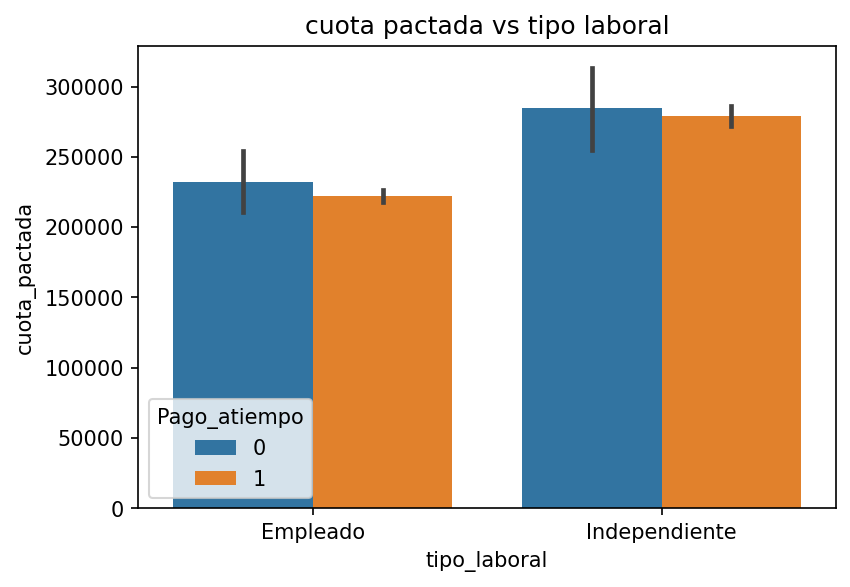

In [398]:
#bivariable
figure3= plt.figure(figsize=(6,4),dpi=150)
sns.barplot(df,x = 'tipo_laboral',y = 'cuota_pactada', hue = 'Pago_atiempo')
plt.title('cuota pactada vs tipo laboral')
plt.show()

#### Se puded observar que el espacio de clientes empleado e independiente sorprendentemente los trabajadores independientes tienden a tomar una cuata de repago más alta.
    El punto a resaltar de esta grafica es que ya sea independiente o empleado si elije pagar la cutoa mas alta de esta categoría tiene una alta probabilidad de no pagar a tiempo.

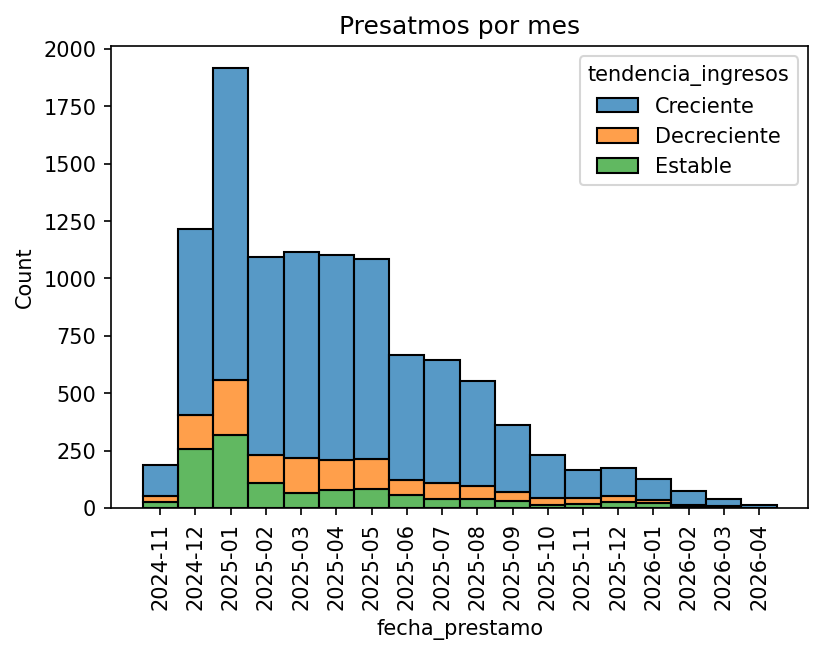

In [407]:
figure3= plt.figure(figsize=(6,4),dpi=150)
sns.histplot(df,x = 'fecha_prestamo', hue = 'tendencia_ingresos', multiple='stack')
plt.title('Presatmos por mes')
plt.xticks(rotation = 90)
plt.show()

#### El grafico muestra que desde noviembre 2024 nuestros clientes han tenido tendencia de ingresos crecientes, sin embargo esa tendencia ha ido disminuyendo a travez de los meses. 
    este comportamiento puded deberse a falta de camapañas de marqeting para atraer clientest que tengan tendencia  de ingresos crecientes con un alto potencial.

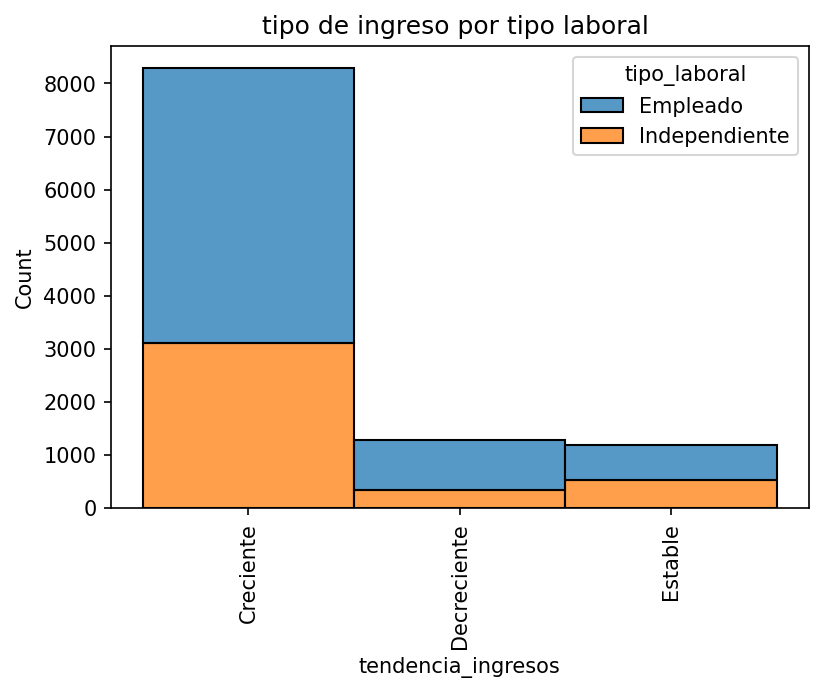

In [406]:
figure3= plt.figure(figsize=(6,4),dpi=150)
sns.histplot(df,x = 'tendencia_ingresos', hue = 'tipo_laboral', multiple= 'stack')
plt.title('tipo de ingreso por tipo laboral ')
plt.xticks(rotation = 90)
plt.show()

#### se puded observar el el plot de arriba que  los clientes con mayor expectativa de mejores ingresos son empleados, sin embargo es de resaltar que este mismo grupo tambíen lidera la cagoría decrediente:
    por tal si se quiere logran estabilidad en los prestamos se podría enfocar en los independientes
    Por otro lado si se busca explotar las oportunidades entonces los empleados son buena opción

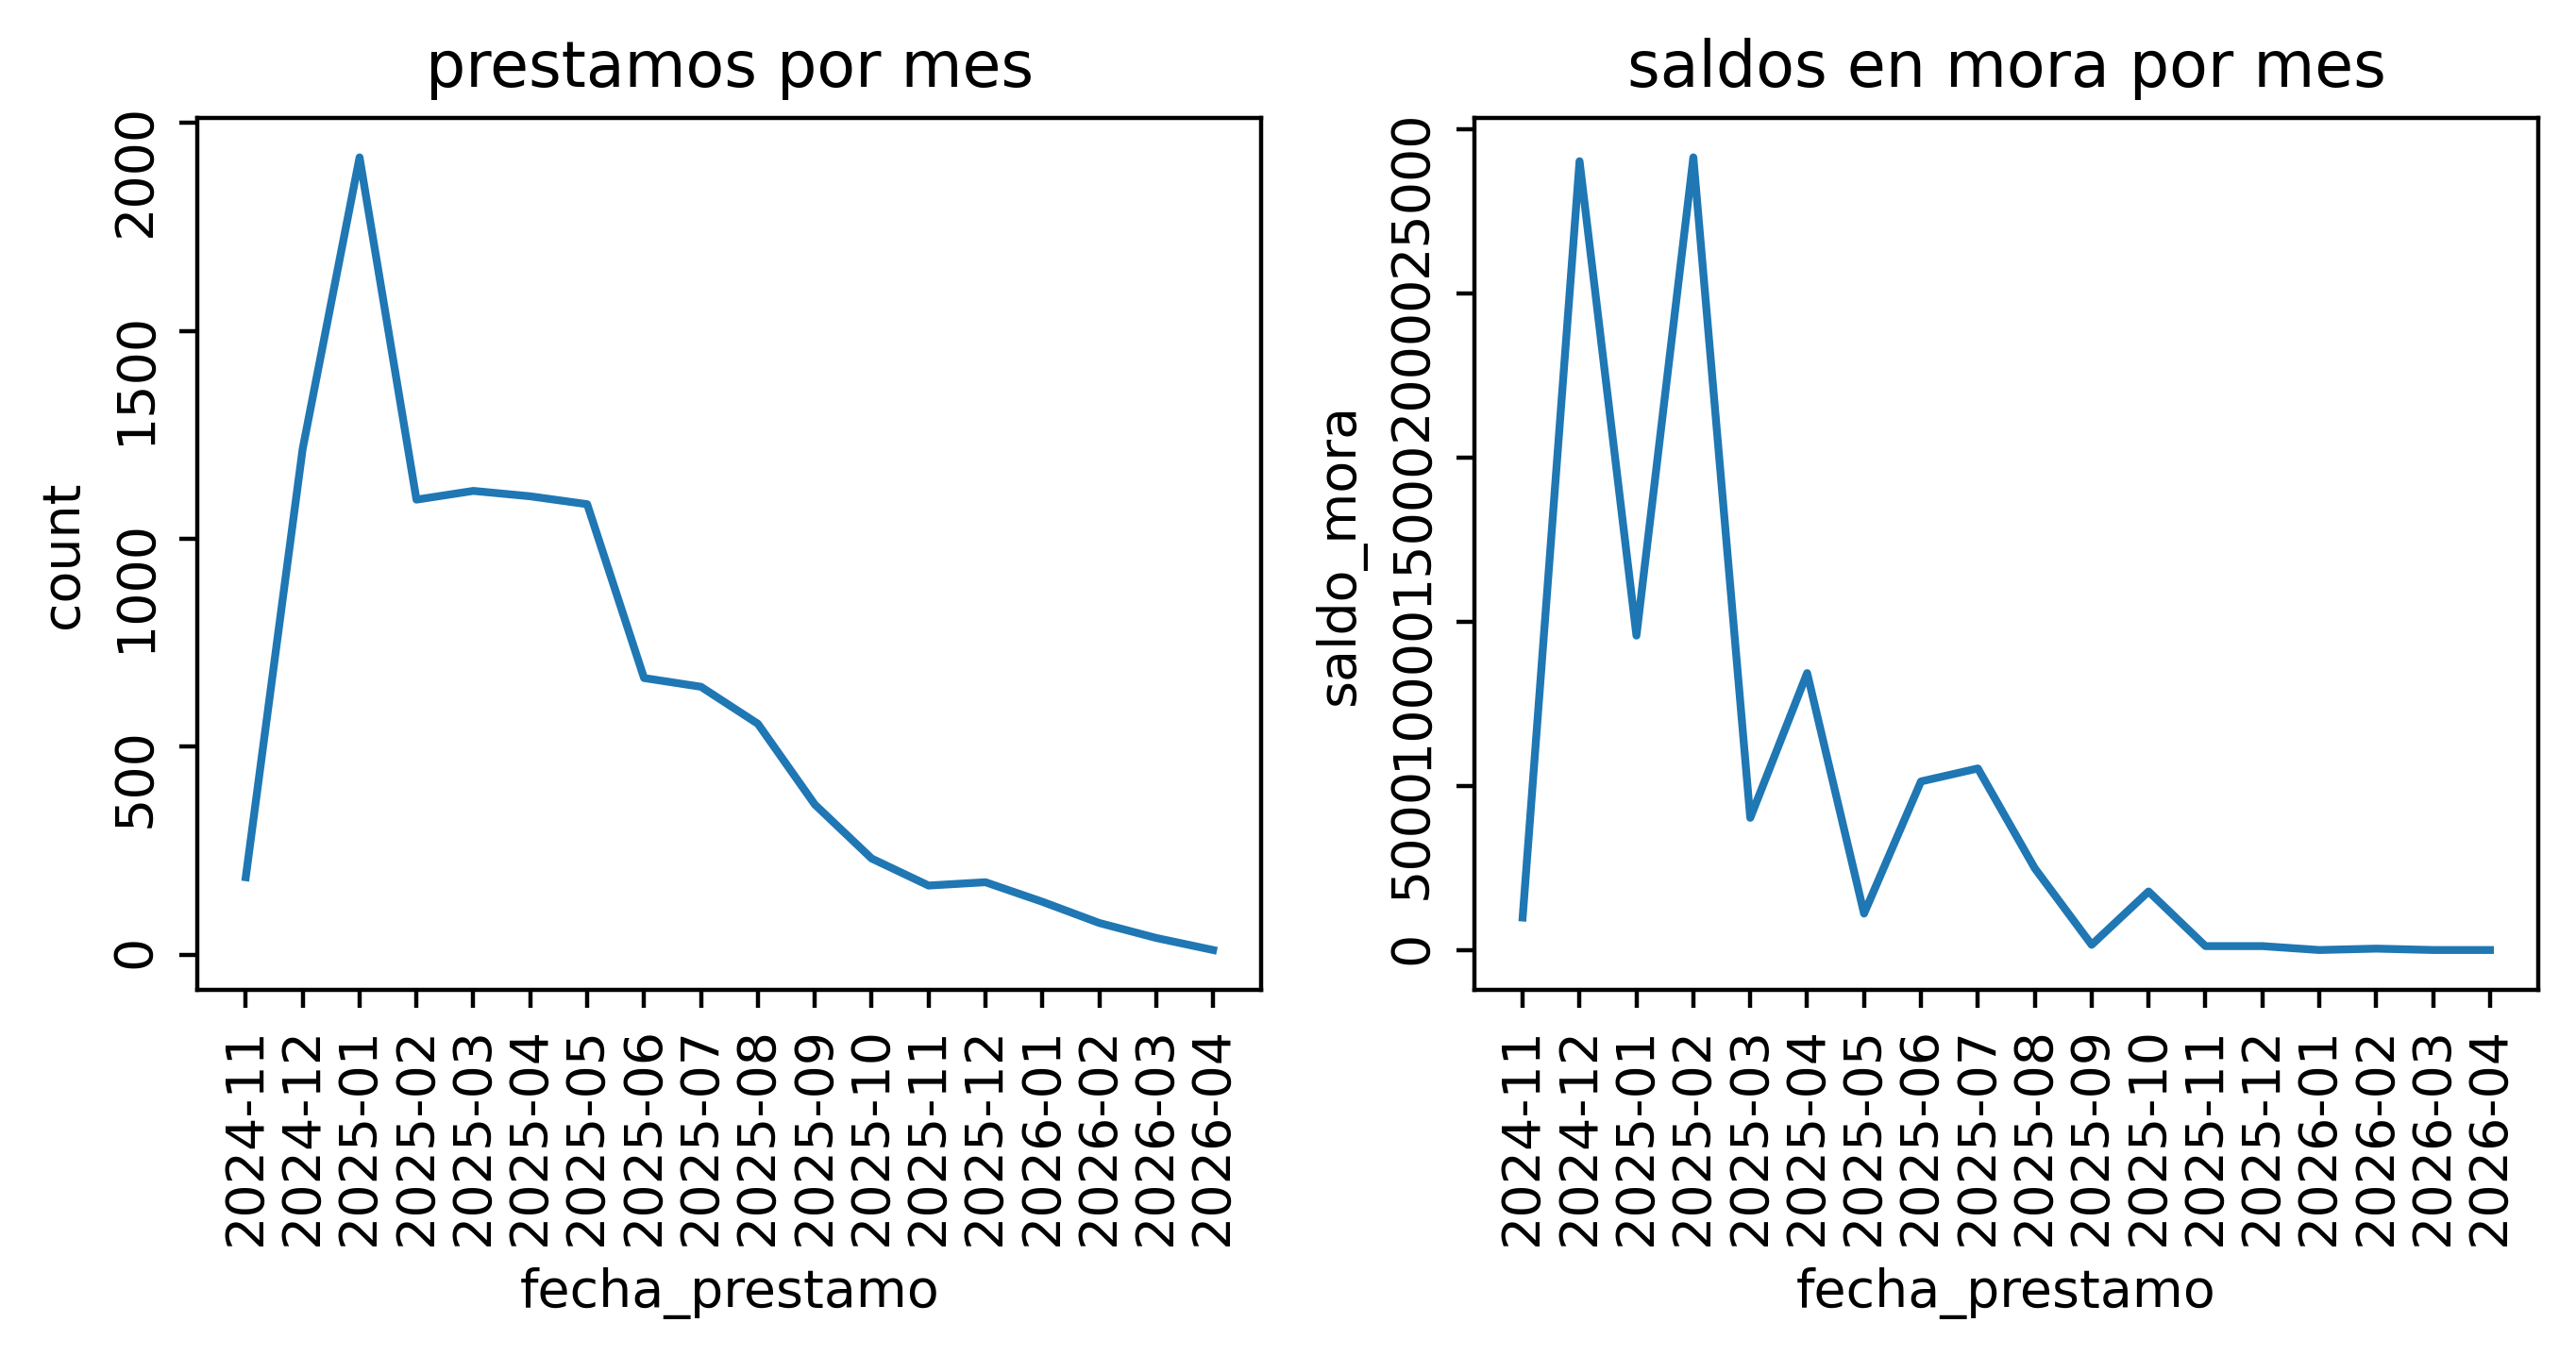

In [412]:
figure3,ax1= plt.subplots(1,2,figsize=(8,3),dpi=400)
df_per_moth = df.groupby('fecha_prestamo')[['capital_prestado','saldo_mora']].sum().reset_index()
df_per_moth = df_per_moth.sort_values('fecha_prestamo')
df_cant_moth = df['fecha_prestamo'].value_counts().reset_index()
df_cant_moth = df_cant_moth.sort_values('fecha_prestamo')

sns.lineplot(df_cant_moth,x = 'fecha_prestamo',y= 'count', ax =ax1[0])
ax1[0].set_title('prestamos por mes')
ax1[0].tick_params(rotation = 90)
sns.lineplot(df_per_moth,x = 'fecha_prestamo', y= 'saldo_mora', errorbar= None, ax =ax1[1])
ax1[1].set_title('saldos en mora por mes')
ax1[1].tick_params(rotation = 90)
plt.show()

#### Este grafico de lines es muy diciente, en primera instancia parece haber undecenso en los saldos en mora, sin embargo mirando a la grafica de la derecha podemos ver que esto esta sucediendo por un decense en la cantidad de prestamos solicitados, lo que debe ser materia de preocupación e investigación.

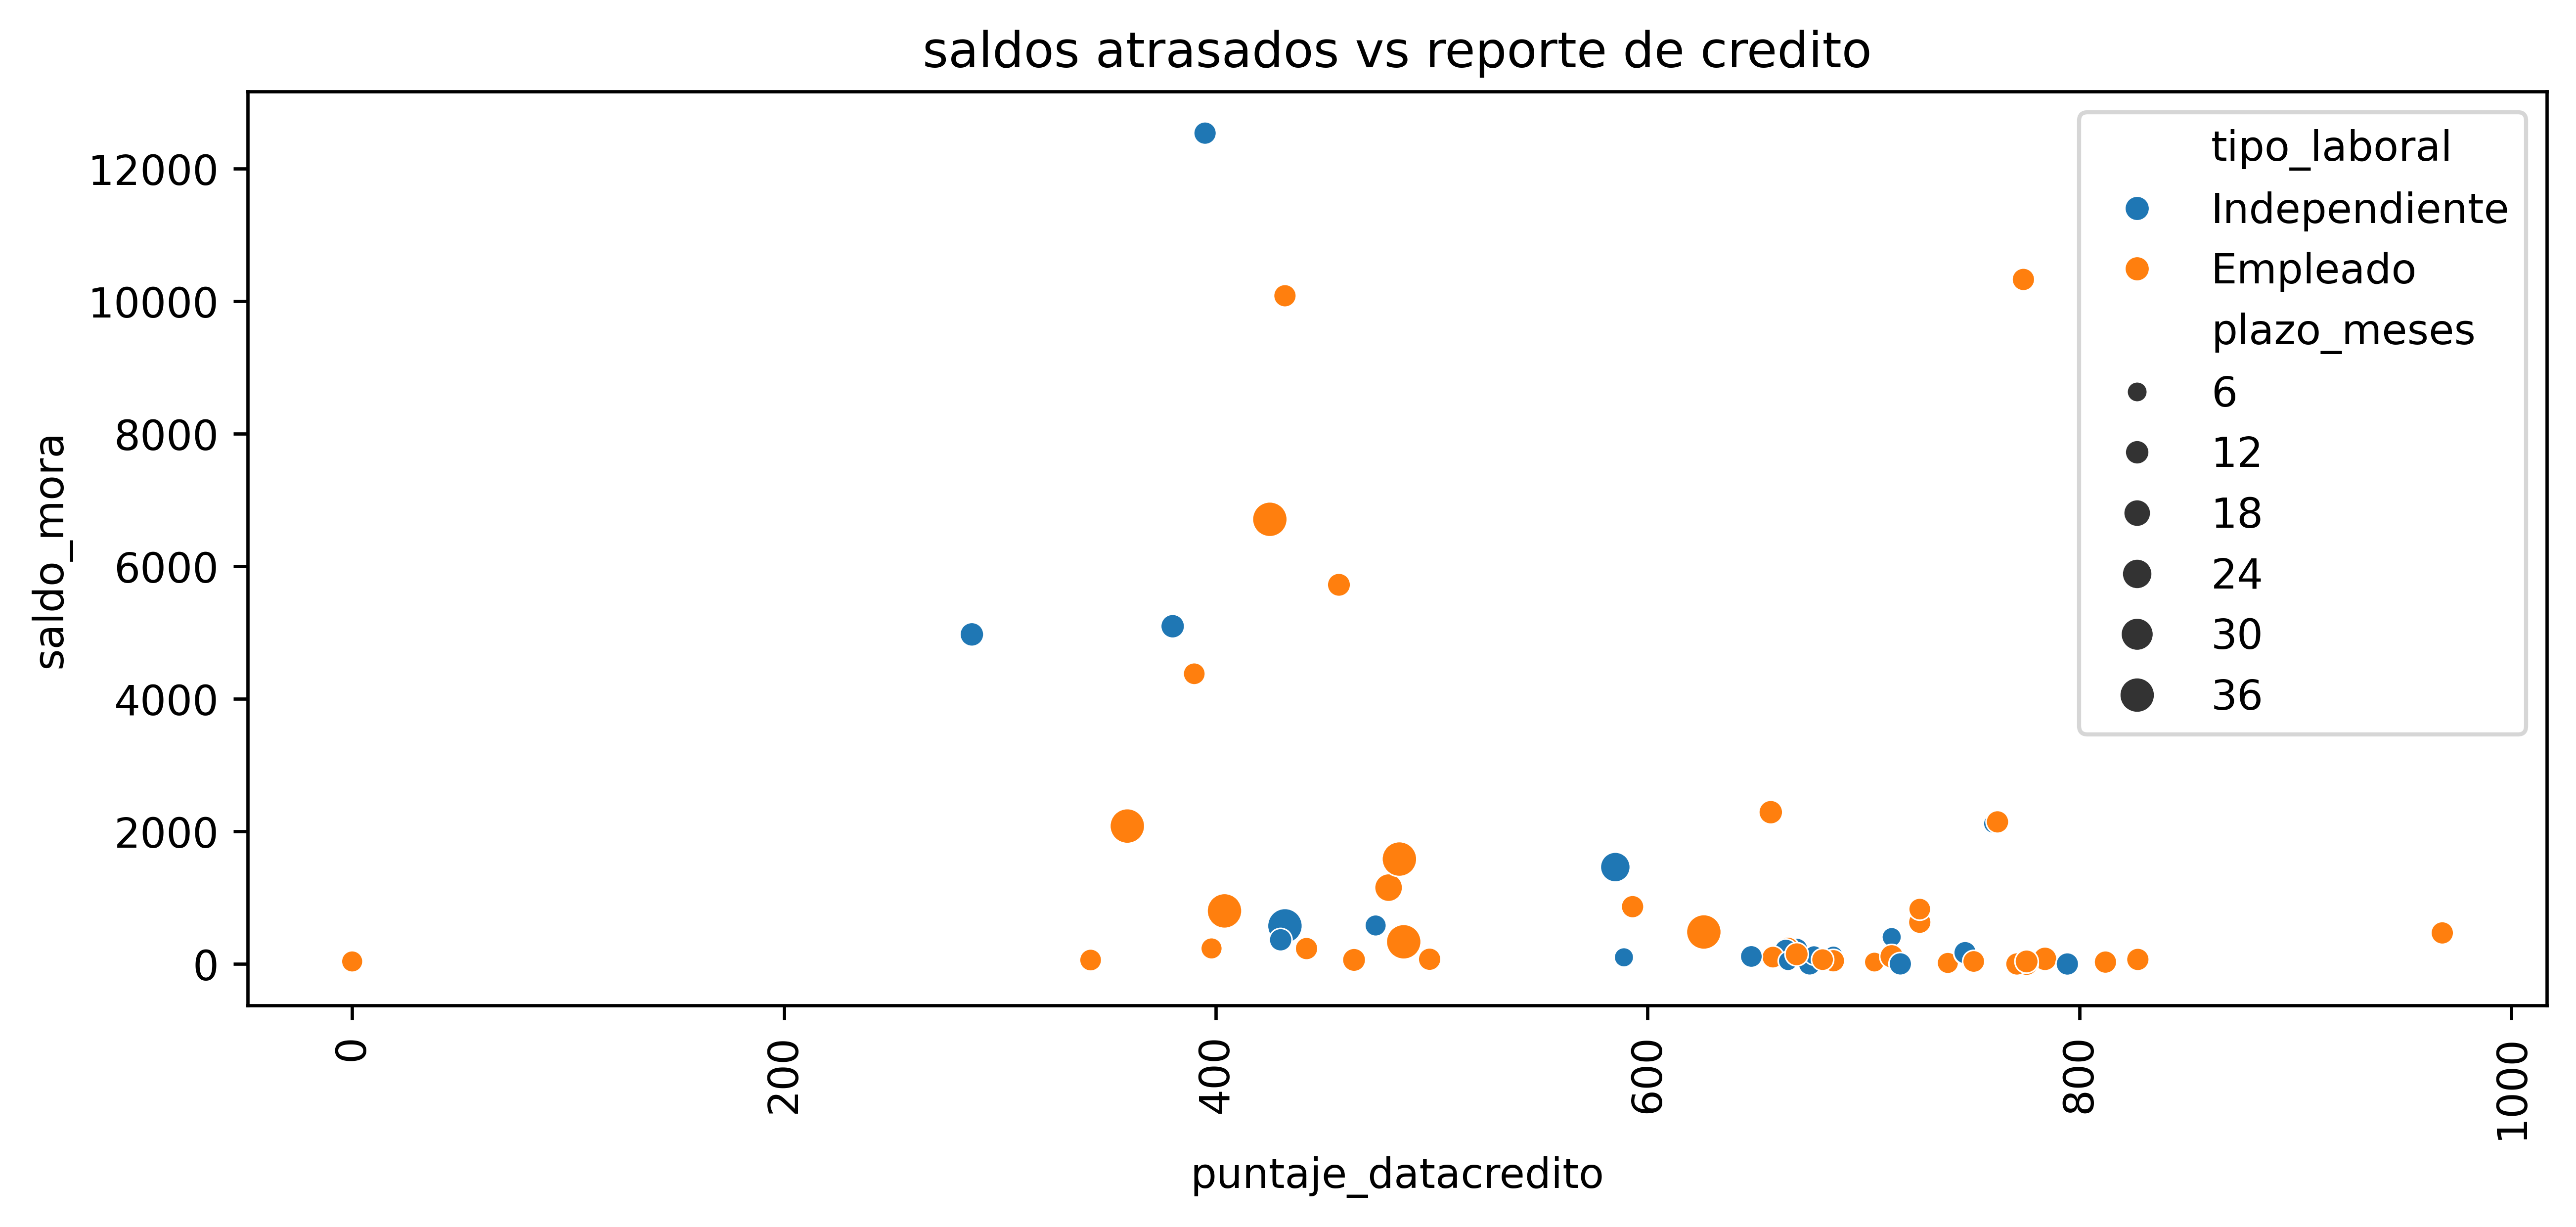

In [413]:
figure3= plt.figure(figsize=(10,4),dpi=600)
mora = df[df['saldo_mora'] > 0]
sns.scatterplot(mora,x = 'puntaje_datacredito',y = 'saldo_mora', hue = 'tipo_laboral',size= 'plazo_meses')
plt.title('saldos atrasados vs reporte de credito')
plt.xticks(rotation = 90)
plt.show()

#### Este grafico muestra la diswtriubicón solo de aquellos que tienen saldos en mora, podemos observar que los mayores saldos en mora son obtenidos por clientes con reportes de creditos de 350 a 500 , si vamos de 58 havia arriba es muy poco probable que alguien pueda tener un saldo en mora mayor a 2000.
    la observación final es que estos clientes siempre tratan de pagar la deuda en los plazos mas cortos